# Clustering Data with Machine Learning

(400, 2) (400,) (4, 2)


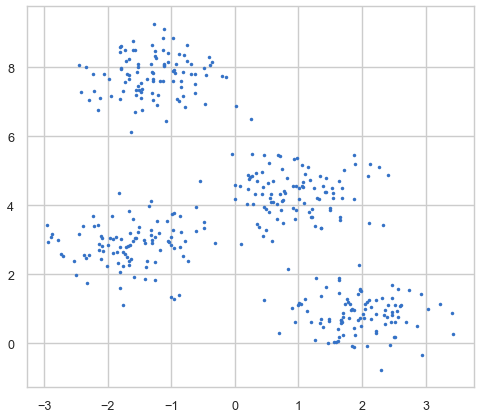

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import IPython.display as ipydis

sns.set_style('whitegrid')
npoints = 400
N = 4
x, cluster_labels, cluster_centers = make_blobs(n_samples=npoints, centers=N,
                       cluster_std=0.60, random_state=0,
                       return_centers=True)
print(x.shape,cluster_labels.shape,cluster_centers.shape)
plt.plot(x[:, 0], x[:, 1],'b.')
plt.plot(cluster_centers[:,0],cluster_centers[:,1],'rx')

In [2]:
def initialize_centroids(x,N):
   x_indices = np.random.choice(np.arange(0,x.shape[0]),N)
   centroids = x[x_indices]
   return centroids

def get_new_centroids(x, labels, N):
    """returns the new centroids assigned from the points closest to them"""
    return np.array([x[labels==k].mean(axis=0) for k in range(N)])

In [3]:
# distance is sqrt( (x - x')**2 + (y - y')**2 )
def assign_labels(x,c):
   # centroids are shape [N,2]
   # x are shape [npoints,2]
   # add middle index to centroids to properly broadcast in math operations
   c = c[:,np.newaxis,:] # [N,1,2]
   
   # calculate (x - x')**2 and (y - y')**2
   # x is shape [npoints,2], c is [N,1,2] results in an array of shape: [N,npoints,2]
   dist2 = (x - c)**2
   
   # calculate (x - x')**2 + (y - y')**2
   dist2 = dist2.sum(axis=2) # [N,npoints]
   
   # out of the N distances, return the index (0-(N-1)) of the one that is the minimum.
   label = np.argmin(dist2,axis=0) # [npoints]

   return label

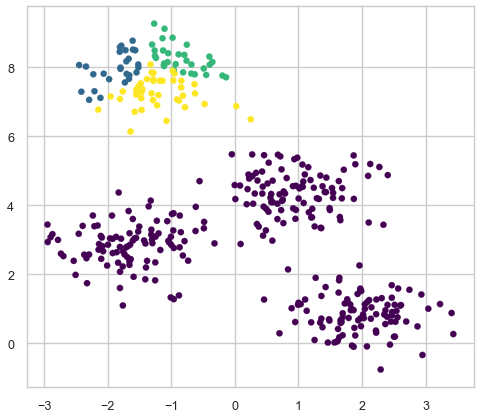

In [4]:
c = initialize_centroids(x,N)
l = assign_labels(x,c)
plt.scatter(x[:, 0], x[:, 1], c=l, s=40, cmap='viridis')

# Homework
Follow the example from the previous notebook [Linear Regression using SGD](./01_linear_regression_sgd.ipynb) and build a loop that properly finds the centers of these 4 clusters using k-means.

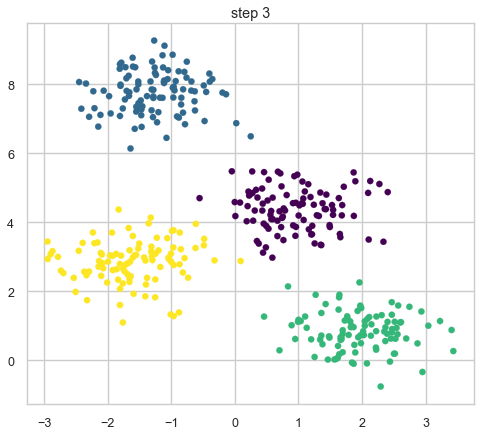

point labels unchanged as of step 3
The centers of the four clusters are at:
 [[ 0.95041055  4.36874542]
 [-1.2689694   7.75608144]
 [ 1.95662677  0.83945671]
 [-1.61366997  2.84849883]]


In [5]:
# set our centroids and label the points
delta = 0.01
last_centroids = initialize_centroids(x,N)
last_labels = assign_labels(x,last_centroids)
step = 0
plt.scatter(x[:, 0], x[:, 1], c=last_labels, s=40, cmap='viridis')
plt.title('step %d' % 0)
plt.show()
time.sleep(1)
ipydis.clear_output(wait=True)


# we run our loop N times
loop_N = 30
for i in range(loop_N):
   
   # update our centroid selection and labels
   centroids = get_new_centroids(x,last_labels,N)
   labels = assign_labels(x,centroids)
  
   # close/delete previous plots
   plt.close('all')
   
   # plot our usual output
   plt.scatter(x[:, 0], x[:, 1], c=last_labels, s=40, cmap='viridis')
   plt.title('step %d' % (i+1))
   plt.show()

   # test if centroids have stopped moving
   if np.all(np.abs(last_centroids - centroids) < delta):
      print('centroids unchanged as of step %d' % (i+1))
      print("The centers of the four clusters are at: ",centroids )
      break
      # done
   elif np.all(labels == last_labels):
      print('point labels unchanged as of step %d' % (i+1))
      print("The centers of the four clusters are at:\n",centroids )
      break
      # done
   else:
      last_labels = labels
      last_centroids = centroids
    
   if(i+1==loop_N): 
     print("End of loop reached")
   
   # gives us time to see the plot
   time.sleep(2.5)
   # clears the plot when the next plot is ready to show.
   ipydis.clear_output(wait=True)
